In [164]:
from datetime import datetime, timezone
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS
from random import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace these with your InfluxDB token, organization, and bucket
org = "ur3e"
bucket = "ur3e"
token = "BkQo1WObUd_cdaOmW3tQfymyGavrrPCmEqPsZwRS3-yTHZzECj5j_6X8MLQRdhbYtTnxKR6rDSi6Wne7g03VBA=="

# Initialize the client
import datetime
client = InfluxDBClient(url="http://localhost:8086", token=token, org=org)
write_api = client.write_api(write_options=SYNCHRONOUS)   
query_api = client.query_api()

In [165]:
time_start = "-1m"
time_stop = "now()"
window = "1s"

query_sensor_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "robotarm.pt.state")
  |> filter(fn: (r) => r["_field"] =~ /(((q_actual|qd_actual|q_target)_[0-6])|(tcp_pose_[0-6]))/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

query_model_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "rt_model.dt.state")
  |> filter(fn: (r) => r["_field"] =~ /[q|qd]_actual_[0-6]/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

df_sensor_data = query_api.query_data_frame(query_sensor_data)
df_model_data = query_api.query_data_frame(query_model_data)

In [166]:
print(df_sensor_data.head())

    result  table                            _time  \
0  _result      0 2026-05-23 14:25:14.790928+00:00   
1  _result      0 2026-05-23 14:25:14.840729+00:00   
2  _result      0 2026-05-23 14:25:14.890021+00:00   
3  _result      0 2026-05-23 14:25:14.940593+00:00   
4  _result      0 2026-05-23 14:25:14.990010+00:00   

                            _start                            _stop  \
0 2026-05-23 14:25:14.778724+00:00 2026-05-23 14:26:14.778724+00:00   
1 2026-05-23 14:25:14.778724+00:00 2026-05-23 14:26:14.778724+00:00   
2 2026-05-23 14:25:14.778724+00:00 2026-05-23 14:26:14.778724+00:00   
3 2026-05-23 14:25:14.778724+00:00 2026-05-23 14:26:14.778724+00:00   
4 2026-05-23 14:25:14.778724+00:00 2026-05-23 14:26:14.778724+00:00   

        _measurement           msg_type  q_actual_0  q_actual_1  q_actual_2  \
0  robotarm.pt.state  PhysicalTwinState    2.788968    3.023419   -2.667742   
1  robotarm.pt.state  PhysicalTwinState    2.736487    3.004506   -2.669448   
2  robotarm

In [167]:
print(df_model_data.head())

    result  table                            _time  \
0  _result      0 2026-05-23 14:25:14.870326+00:00   
1  _result      0 2026-05-23 14:25:14.920303+00:00   
2  _result      0 2026-05-23 14:25:14.970261+00:00   
3  _result      0 2026-05-23 14:25:15.020658+00:00   
4  _result      0 2026-05-23 14:25:15.070446+00:00   

                            _start                            _stop  \
0 2026-05-23 14:25:14.863294+00:00 2026-05-23 14:26:14.863294+00:00   
1 2026-05-23 14:25:14.863294+00:00 2026-05-23 14:26:14.863294+00:00   
2 2026-05-23 14:25:14.863294+00:00 2026-05-23 14:26:14.863294+00:00   
3 2026-05-23 14:25:14.863294+00:00 2026-05-23 14:26:14.863294+00:00   
4 2026-05-23 14:25:14.863294+00:00 2026-05-23 14:26:14.863294+00:00   

        _measurement             msg_type  q_actual_0  q_actual_1  q_actual_2  \
0  rt_model.dt.state  KinematicModelState    2.634669    2.967814   -2.672759   
1  rt_model.dt.state  KinematicModelState    2.582309    2.948945   -2.674462   
2  rt

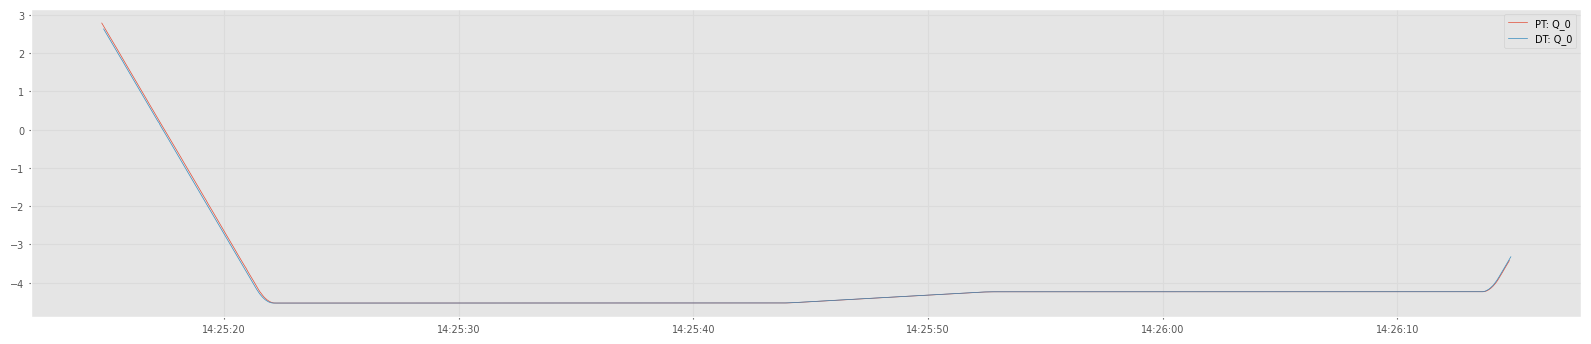

In [168]:
q0_sensor = df_sensor_data["q_actual_0"].to_numpy()
q0_model = df_model_data["q_actual_0"].to_numpy()

t_sensor = df_sensor_data["_time"].to_numpy()
t_model = df_model_data["_time"].to_numpy()

plt.figure(figsize=(20, 4))

plt.plot(t_sensor, q0_sensor, label="PT: Q_0")
plt.plot(t_model, q0_model, label="DT: Q_0")
plt.legend()

In [169]:
df_sensor_data.to_numpy().shape

(1196, 31)

In [170]:
sensor_data_np = np.hstack([df_sensor_data.to_numpy()[:, 7:13], df_sensor_data.to_numpy()[:, 19:25]])
t_sensor = df_sensor_data["_time"].to_numpy()

model_data_np = df_model_data.to_numpy()[:, 7:]
t_model = df_model_data["_time"].to_numpy()

In [171]:
sensor_data_np.shape, model_data_np.shape

((1196, 12), (1197, 12))

In [172]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

def calculate_time_aligned_mae(t_sensor, sensor_data, t_model, model_data):
    # Convert to standard pandas datetime (handles Timestamp objects safely)
    # Then cast to int64 (nanoseconds since epoch) to get raw numbers for scipy
    t_sensor_num = pd.to_datetime(t_sensor).astype('int64')
    t_model_num = pd.to_datetime(t_model).astype('int64')
    
    # Create the interpolator along the time axis (axis=0)
    model_interpolator = interp1d(
        t_model_num, 
        model_data, 
        axis=0, 
        bounds_error=False, 
        fill_value="extrapolate"
    )
    
    # Interpolate model data to match the 5965 sensor timestamps
    model_data_aligned = model_interpolator(t_sensor_num)
    
    # Calculate Mean Squared Error across the 12 signals (axis 1)
    mse_over_time = np.mean(np.abs(sensor_data - model_data_aligned), axis=1)
    
    return mse_over_time

In [173]:
mae = calculate_time_aligned_mae(t_sensor, sensor_data_np, t_model, model_data_np)

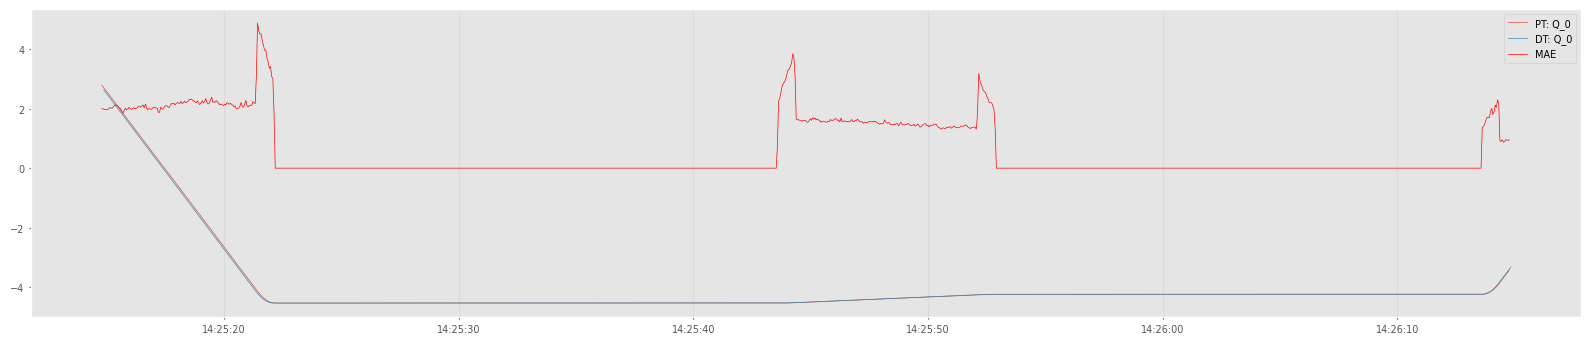

In [174]:
i = 0
q = True

q0_sensor = df_sensor_data[f"{'q' if q else 'qd'}_actual_{i}"].to_numpy()
q0_model = df_model_data[f"{'q' if q else 'qd'}_actual_{i}"].to_numpy()

t_sensor = df_sensor_data["_time"].to_numpy()
t_model = df_model_data["_time"].to_numpy()

plt.figure(figsize=(20, 4))

plt.plot(t_sensor, q0_sensor, label="PT: Q_0")
plt.plot(t_model, q0_model, label="DT: Q_0")
plt.plot(t_sensor, mae*100, label="MAE", color="red")
plt.grid(axis="y")
plt.legend()

In [175]:
# Calculate mean MSE over entire signal
np.mean(mae)

0.0057502483281479545

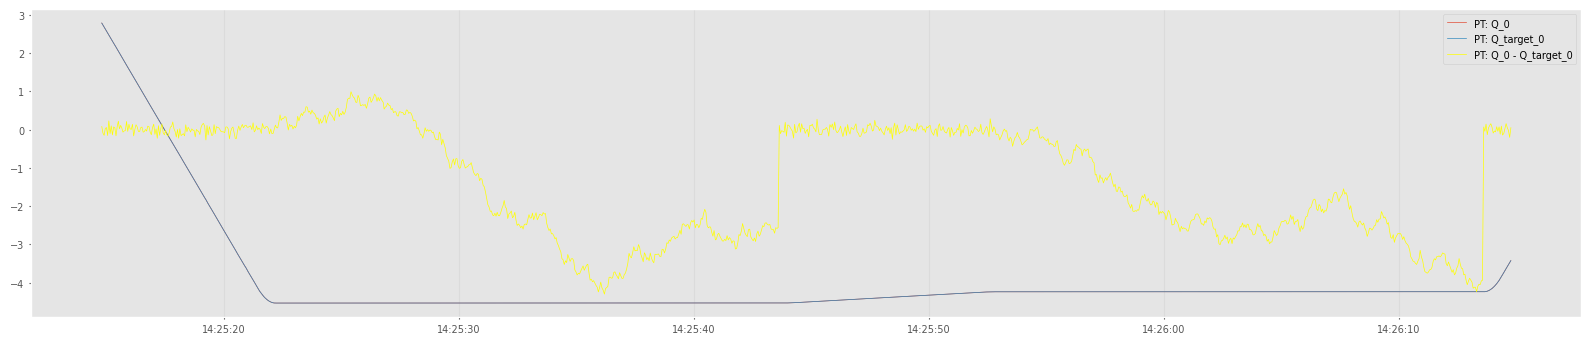

In [176]:
i = 0
q = True

q0_sensor = df_sensor_data[f"{'q' if q else 'qd'}_actual_{i}"].to_numpy()
q0_model = df_model_data[f"{'q' if q else 'qd'}_actual_{i}"].to_numpy()
q0_target = df_sensor_data[f"{'q' if q else 'qd'}_target_{i}"].to_numpy()

t_sensor = df_sensor_data["_time"].to_numpy()
t_model = df_model_data["_time"].to_numpy()

plt.figure(figsize=(20, 4))

plt.plot(t_sensor, q0_sensor, label="PT: Q_0")
# plt.plot(t_model, q0_model, label="DT: Q_0")
plt.plot(t_sensor, q0_target, label="PT: Q_target_0")
plt.plot(t_sensor, (q0_sensor - q0_target)*1000000, label="PT: Q_0 - Q_target_0", color="yellow")
# plt.plot(t_sensor, mae*100, label="MAE", color="red")
plt.grid(axis="y")
plt.legend()

Calculating Forward Kinematics for all time steps...


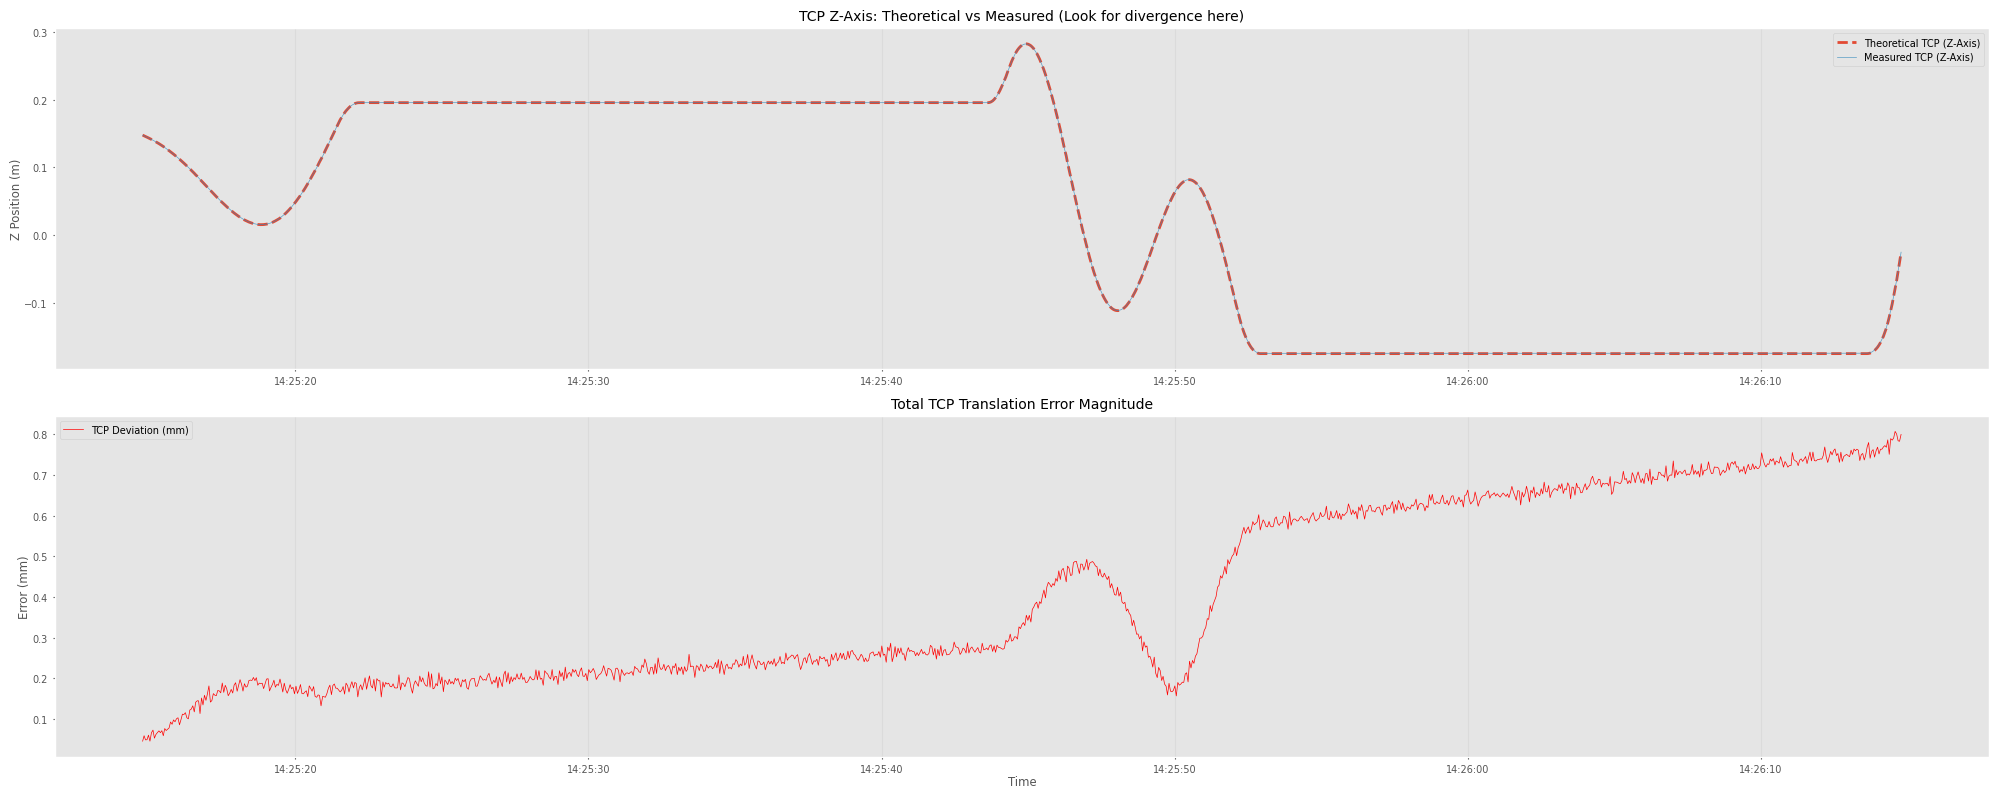

In [177]:
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

# 1. Extract Time
t_sensor = df_sensor_data["_time"].to_numpy()
n_samples = len(t_sensor)

# 2. Extract all 6 Joint Angles (q_actual)
q_actual = np.zeros((n_samples, 6))
for i in range(6):
    q_actual[:, i] = df_sensor_data[f"q_actual_{i}"].to_numpy()

# 3. Extract Measured TCP Translation (Assuming indices 0, 1, 2 are X, Y, Z)
tcp_measured = np.zeros((n_samples, 3))
for i in range(3):
    tcp_measured[:, i] = df_sensor_data[f"tcp_pose_{i}"].to_numpy()

# 4. Calculate Theoretical TCP using Forward Kinematics
# Load the standard UR3e DH parameters
link1 = rtb.RevoluteDH(d=0.15185, a=0.0,      alpha=np.pi / 2)
link2 = rtb.RevoluteDH(d=0.0,     a=-0.24355, alpha=0.0)
link3 = rtb.RevoluteDH(d=0.0,     a=-0.2132,  alpha=0.0)
link4 = rtb.RevoluteDH(d=0.13105, a=0.0,      alpha=np.pi / 2)
link5 = rtb.RevoluteDH(d=0.08535, a=0.0,      alpha=-np.pi / 2)
link6 = rtb.RevoluteDH(d=0.0921,  a=0.0,      alpha=0.0)
robot = rtb.DHRobot([link1, link2, link3, link4, link5, link6], name="My_UR3e")
tcp_theoretical = np.zeros((n_samples, 3))

print("Calculating Forward Kinematics for all time steps...")
for j in range(n_samples):
    # .fkine() returns an SE3 transformation matrix
    # .t extracts the [X, Y, Z] translation vector
    tcp_theoretical[j, :] = robot.fkine(q_actual[j, :]).t

# 5. Calculate the Error Magnitude (Euclidean distance)
# This gives us the total deviation in 3D space between the theoretical and actual tool position
tcp_error_m = np.linalg.norm(tcp_theoretical[:, :3] - tcp_measured[:, :3], axis=1)
tcp_error_mm = tcp_error_m * 1000  # Convert to mm for easier reading

# 6. Plotting
plt.figure(figsize=(20, 8))

# Subplot 1: Z-Axis comparison (Where sag/backlash is most obvious)
plt.subplot(2, 1, 1)
plt.plot(t_sensor, tcp_theoretical[:, 2], label="Theoretical TCP (Z-Axis)", linestyle="--", linewidth=2)
plt.plot(t_sensor, tcp_measured[:, 2], label="Measured TCP (Z-Axis)", alpha=0.8)
plt.title("TCP Z-Axis: Theoretical vs Measured (Look for divergence here)")
plt.ylabel("Z Position (m)")
plt.grid(axis="y")
plt.legend()

# Subplot 2: Total TCP Error
plt.subplot(2, 1, 2)
plt.plot(t_sensor, tcp_error_mm, label="TCP Deviation (mm)", color="red")
plt.title("Total TCP Translation Error Magnitude")
plt.ylabel("Error (mm)")
plt.xlabel("Time")
plt.grid(axis="y")
plt.legend()

plt.tight_layout()
plt.show()